# 16.2 · Chessboard calibration and reprojection

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain chessboard calibration and reprojection using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [07 · Geometric Transformations](../../07-geometric-transformations/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Calibration estimates how a camera maps three-dimensional points to image pixels. Intrinsics describe the camera coordinate system and pixel scaling; extrinsics describe camera pose relative to a world frame. Lens distortion adds departures from the ideal pinhole model.

## 2. Intuition

A calibration board supplies known points in a plane. Observe it at varied angles and positions, detect corners and minimize reprojection error across views. Reprojection error measures agreement with detected image points; it does not by itself guarantee accurate depth. The lab uses known synthetic board poses and compares recovered parameters with truth.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 16
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
u=f_xX/Z+c_x,\qquad v=f_yY/Z+c_y
$$

X,Y,Z are camera-frame coordinates, fx,fy focal lengths in pixels, and cx,cy principal point. With X=0.2 m, Z=2 m, fx=400 px and cx=320 px, u=360 px.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
X, Z, fx, cx = 0.2, 2.0, 400.0, 320.0
u = fx * X / Z + cx
assert np.isclose(u, 360)
print(u)

360.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The synthetic lab projects a grid through known intrinsics and poses, adds pixel noise and calls calibrateCamera. The reported parameter error is meaningful because synthetic truth is available.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def calibration(lesson, seed, amount):
    rng = np.random.default_rng(seed)
    board = np.zeros((6 * 7, 3), np.float32)
    board[:, :2] = np.mgrid[:7, :6].T.reshape(-1, 2) * 0.03
    true_k = np.array([[300.0, 0, 160], [0, 305, 120], [0, 0, 1.0]])
    objects = []
    images = []
    for index in range(10):
        rvec = np.array([0.1 + index * 0.025, 0.15 * np.sin(index), 0.04 * index])
        tvec = np.array([-0.09 + 0.01 * np.cos(index), -0.08, 0.65 + index * 0.025])
        projected, _ = cv2.projectPoints(board, rvec, tvec, true_k, np.zeros(5))
        projected += rng.normal(0, 0.1 * amount, projected.shape)
        objects.append(board)
        images.append(projected.astype(np.float32))
    rms, k, dist, _, _ = cv2.calibrateCamera(objects, images, (320, 240), None, None)
    canvas = np.zeros((240, 320, 3), np.uint8)
    for x, y in images[0].reshape(-1, 2):
        cv2.circle(canvas, (int(x), int(y)), 2, (100, 230, 160), -1)
    return Result(
        "16 · Pinhole camera calibration from multiple views",
        {
            "One projected chessboard view": canvas,
            "True intrinsics": true_k,
            "Estimated intrinsics": k,
        },
        metrics={
            "reprojection_rms_px": float(rms),
            "focal_relative_error": float(abs(k[0, 0] - 300) / 300),
            "view_count": 10,
        },
        notes="Known synthetic camera; real calibration needs diverse board orientations, an actual square size and held-out reprojection checks.",
    )

{
  "reprojection_rms_px": 0.135913415853444,
  "focal_relative_error": 0.024105701706544663,
  "view_count": 10
}
Known synthetic camera; real calibration needs diverse board orientations, an actual square size and held-out reprojection checks.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import project

display(Code(inspect.getsource(project), language="python"))

def project(points, matrix):
    """Project world XYZ through a 3x4 matrix into pixel xy; require finite depth."""
    q = homogeneous(points) @ np.asarray(matrix).T
    if np.any(np.abs(q[:, 2]) < 1e-12):
        raise ValueError("Point projects to zero homogeneous depth.")
    return q[:, :2] / q[:, 2:3]

## 8. Experiment

Use many nearly identical front-facing board views versus varied views. Compare parameter stability, not just training reprojection error.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "reprojection_rms_px": 0.135913415853444,
    "focal_relative_error": 0.024105701706544663,
    "view_count": 10
  },
  "second_seed": {
    "reprojection_rms_px": 0.13752016283694776,
    "focal_relative_error": 0.043573667892747685,
    "view_count": 10
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

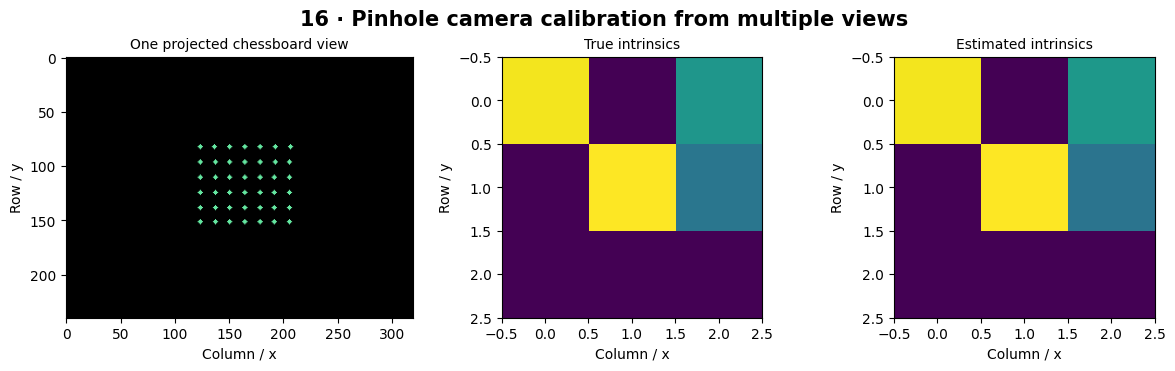

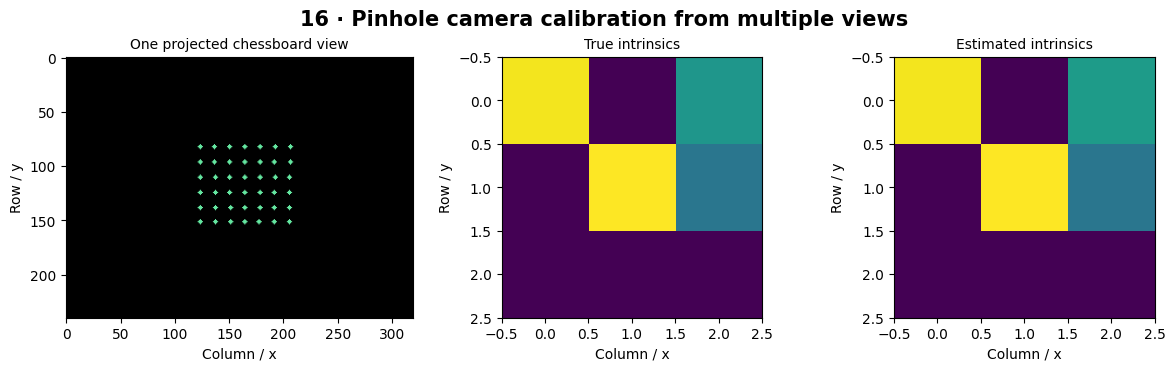

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Camera Calibration Toolkit**. Calibrate a camera and validate on held-out board views. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Chessboard dimensions count inner corners, not squares. Mixing units changes estimated translations and baseline scale.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Use many nearly identical front-facing board views versus varied views. Compare parameter stability, not just training reprojection error.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a calibration toolkit that saves K, distortion, image size, board units and per-view errors, and rejects an empty detection set.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A calibration board supplies known points in a plane. Observe it at varied angles and positions, detect corners and minimize reprojection error across views. Reprojection error measures agreement with detected image points; it does not by itself guarantee accurate depth. The lab uses known synthetic board poses and compares recovered parameters with truth.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Distortion, undistortion and validation** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)